In [1]:
from pathlib import Path
import uproot 
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_path = Path("/pscratch/sd/h/hrzhao/Dataset/outreach/samples")

In [3]:
sig_H5p_m300 = data_path / "signal_H5p" / "H5p_m300_546843" / "mc20a"
assert sig_H5p_m300.exists(), f"Path {sig_H5p_m300} does not exist"

bkg_WZ_QCD = data_path / "samples" / "bkg_H5p" / "WZ_QCD_700601" / "mc20a" / "user.jmcgowan.42020821._000001.ANALYSIS.root"
assert bkg_WZ_QCD.exists(), f"Path {bkg_WZ_QCD} does not exist"

In [4]:
sig_H5p_m300 = uproot.open(sig_H5p_m300)
print(sig_H5p_m300.keys())

bkg_WZ_QCD = uproot.open(bkg_WZ_QCD)
print(bkg_WZ_QCD.keys())

['defaultTree;1']
['defaultTree;1']


In [5]:
sig_H5p_m300_tree = sig_H5p_m300["defaultTree;1"]
bkg_WZ_QCD_tree = bkg_WZ_QCD["defaultTree;1"]

In [11]:
all_nominal_branch_names = sig_H5p_m300_tree.keys(filter_name='*_NOSYS')
all_weight_names = sig_H5p_m300_tree.keys(filter_name='*weight*')

In [23]:
len(all_nominal_branch_names)

151

In [40]:
# write out all_nominal_branch_names 
with open("all_nominal_branch_names.txt", "w") as f:
    for branch in all_nominal_branch_names:
        f.write(f"{branch}\n")

In [ ]:
# print the first 10 branch names
print(all_nominal_branch_names[:10])

# print the weight names
print(all_weight_names)

['Et_ll_NOSYS', 'H_t_NOSYS', 'MT_dilep_NOSYS', 'MT_trilep_NOSYS', 'weight_pileup_NOSYS', 'RNNScore_NOSYS', 'bjet_n_NOSYS', 'dEta_jj_NOSYS', 'dPhi_jj_NOSYS', 'dPhi_ll_NOSYS']
['weight_fake_WZ_selections', 'weight_fake_ssWW_selections', 'weight_beamspot', 'weight_pileup_NOSYS', 'weight_fjvt_effSF_NOSYS', 'weight_mc_NOSYS', 'weight_jvt_effSF_NOSYS']


In [37]:
# define the baseline criteria
WZ_baseline = ["pass_WZ_baseline_NOSYS"]

# choose several branches to plot
selected_features = [
    "el_pt_NOSYS", "el_z0sinth_NOSYS", "el_select_LooseBLayerLH_NOSYS", "el_select_Loose_VarRad_NOSYS", # used for SR selection due to bugs
    "mu_pt_NOSYS", "mu_z0sinth_NOSYS", "mu_d0_NOSYS", "mu_d0sig_NOSYS", "mu_select_Medium_NOSYS", "mu_select_PflowTight_VarRad_NOSYS", # no mu_eta, for SR selection due to bugs
    "el_e_NOSYS", "el_d0_NOSYS", "el_z0_NOSYS",
    "jet_e_NOSYS", "jet_pt_NOSYS", "jet1_pt_NOSYS", "jet2_pt_NOSYS",
    "mjj_NOSYS", "dEta_jj_NOSYS", "MT_trilep_NOSYS", "Et_ll_NOSYS", "H_t_NOSYS", "MT_dilep_NOSYS", "pt_ll_NOSYS",
    ]
weights = ["weight_mc_NOSYS"]

In [38]:
# load the data into a awkward array
sig_H5p_m300_features = sig_H5p_m300_tree.arrays(WZ_baseline + selected_features + weights, library="ak")
sig_H5p_m300_features = sig_H5p_m300_features[sig_H5p_m300_features["pass_WZ_baseline_NOSYS"] == 1]

bkg_WZ_QCD_features = bkg_WZ_QCD_tree.arrays(WZ_baseline + selected_features + weights, library="ak")
bkg_WZ_QCD_features = bkg_WZ_QCD_features[bkg_WZ_QCD_features["pass_WZ_baseline_NOSYS"] == 1]

In [46]:
sig_H5p_m300_features

<Array [{...}, {...}, {...}, ..., {...}, {...}] type='9020 * {pass_WZ_basel...'>

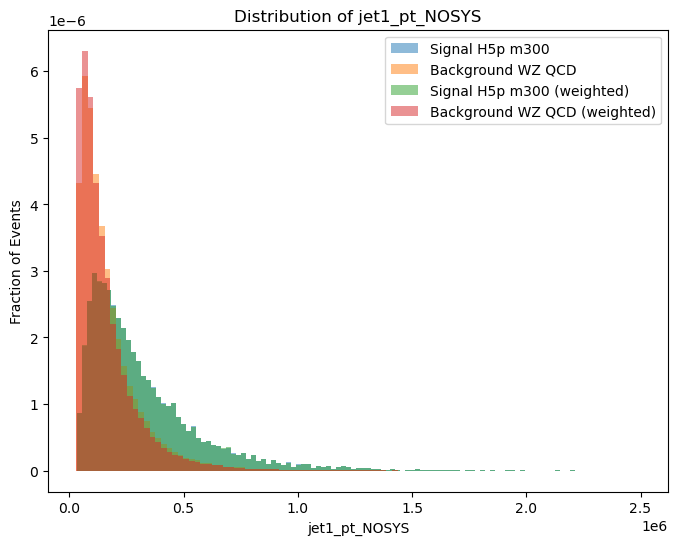

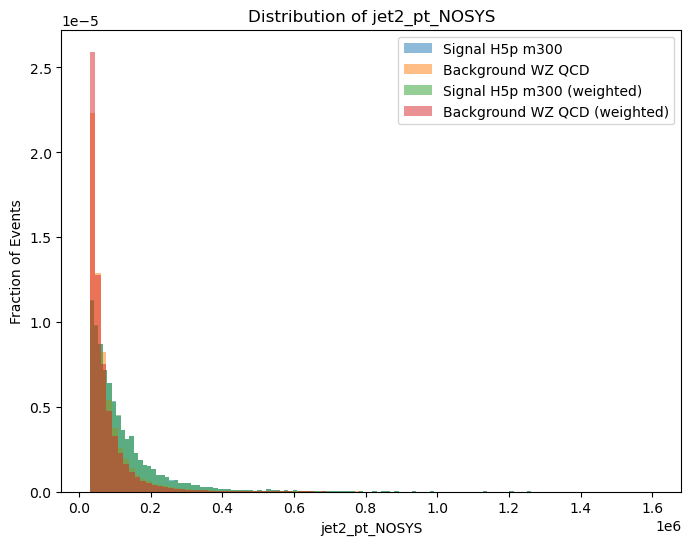

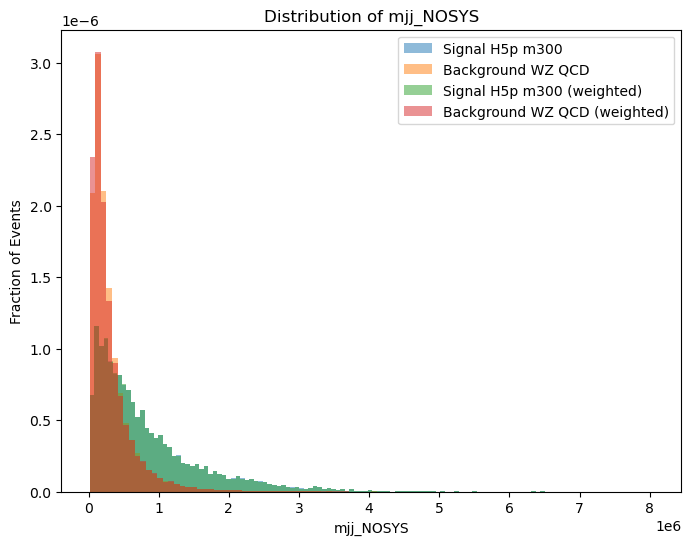

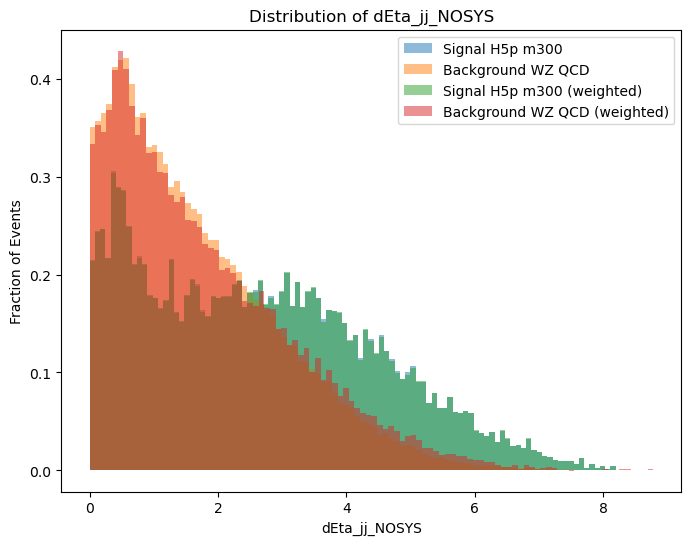

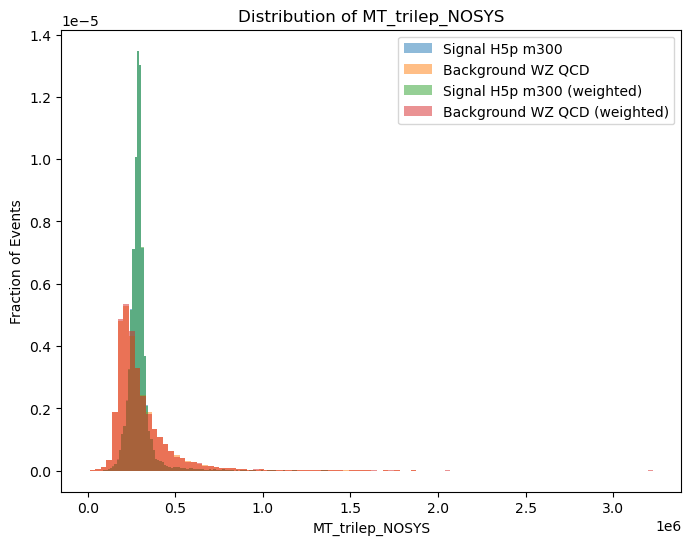

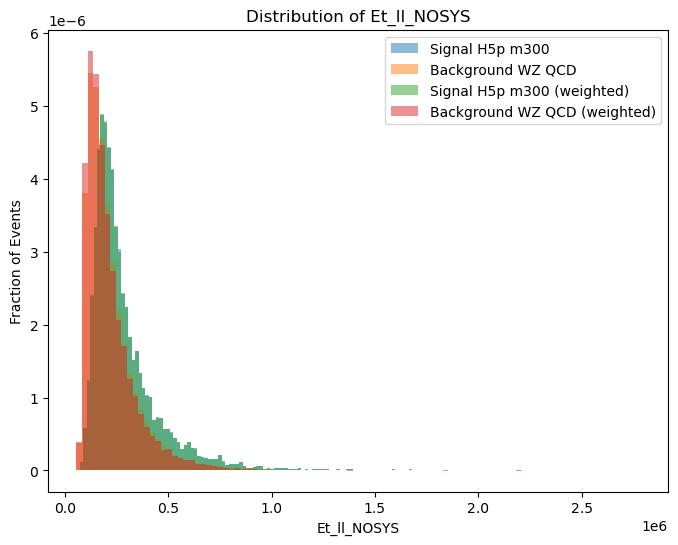

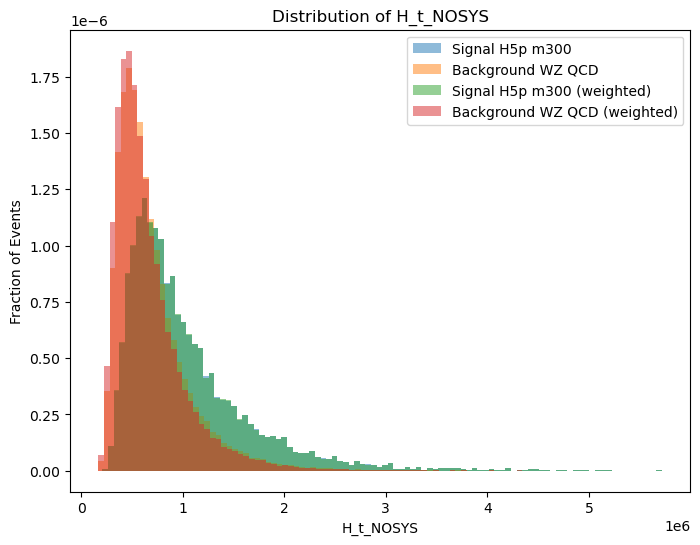

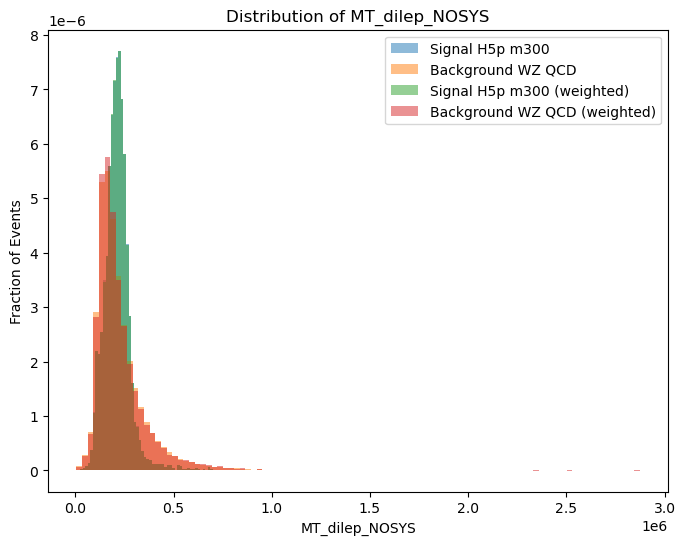

In [57]:
# for each feature, plot the distribution for signal and background w/ and w/o event weights 
for feature in selected_features[-9:-1]:
    plt.figure(figsize=(8, 6))
    plt.hist(sig_H5p_m300_features[feature], bins=100, alpha=0.5, label="Signal H5p m300", density=True)
    plt.hist(bkg_WZ_QCD_features[feature], bins=100, alpha=0.5, label="Background WZ QCD", density=True)

    plt.hist(sig_H5p_m300_features[feature], weights=sig_H5p_m300_features["weight_mc_NOSYS"], bins=100, alpha=0.5, label="Signal H5p m300 (weighted)", density=True)
    plt.hist(bkg_WZ_QCD_features[feature], weights=bkg_WZ_QCD_features["weight_mc_NOSYS"], bins=100, alpha=0.5, label="Background WZ QCD (weighted)", density=True)

    plt.xlabel(feature)
    plt.ylabel("Fraction of Events")
    plt.title(f"Distribution of {feature}")
    plt.legend()
    plt.show()